Kuramoto Oscillator Associative Memory for OCR
X shape: (3823, 64)
y shape: (3823,)
Labels: [0 1 2 3 4 5 6 7 8 9]
Digit 0: 376 samples
Digit 1: 389 samples
Digit 2: 380 samples
Digit 3: 389 samples
Digit 4: 387 samples
Digit 5: 376 samples
Digit 6: 377 samples
Digit 7: 387 samples
Digit 8: 380 samples
Digit 9: 382 samples

X_norm min/max: 0.0 1.0
Phi min/max: 0.0 3.141592653589793
Computed C matrix for digit 0, samples = 376
Computed C matrix for digit 1, samples = 389
Computed C matrix for digit 2, samples = 380
Computed C matrix for digit 3, samples = 389
Computed C matrix for digit 4, samples = 387
Computed C matrix for digit 5, samples = 376
Computed C matrix for digit 6, samples = 377
Computed C matrix for digit 7, samples = 387
Computed C matrix for digit 8, samples = 380
Computed C matrix for digit 9, samples = 382
C_classes shape: (10, 64, 64)

W shape: (64, 64)
W min/max: -0.003580052213455932 0.00625


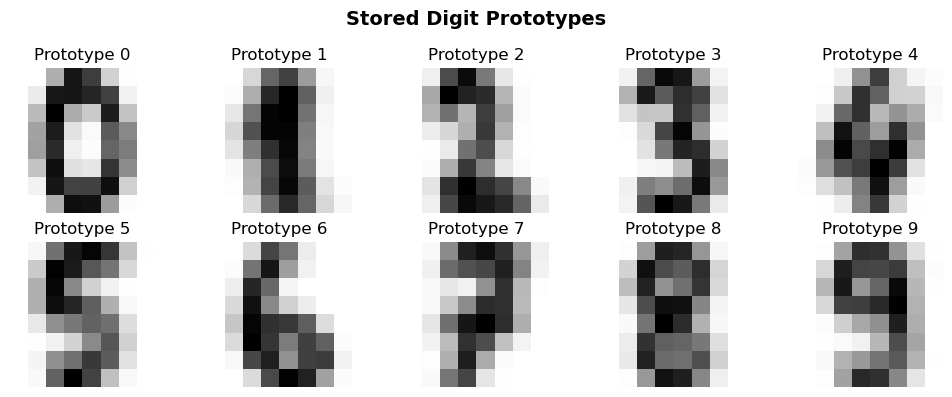


=== Recognition Examples: Clean + Noisy for Digits 0-9 ===

Digit 0


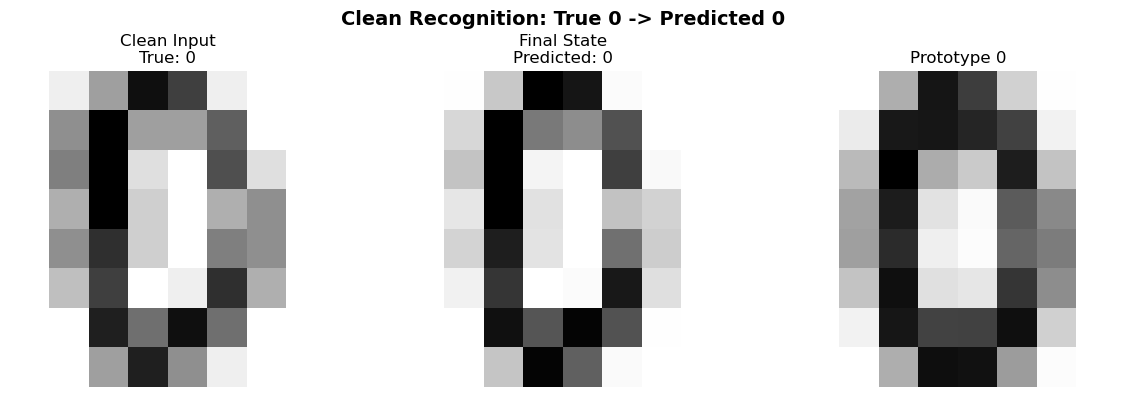

Clean prediction: 0


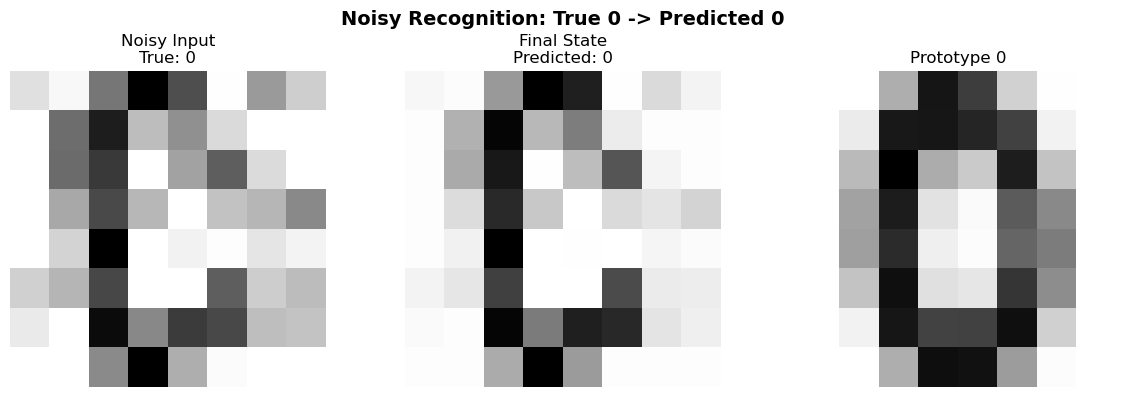

Noisy prediction: 0

Digit 1


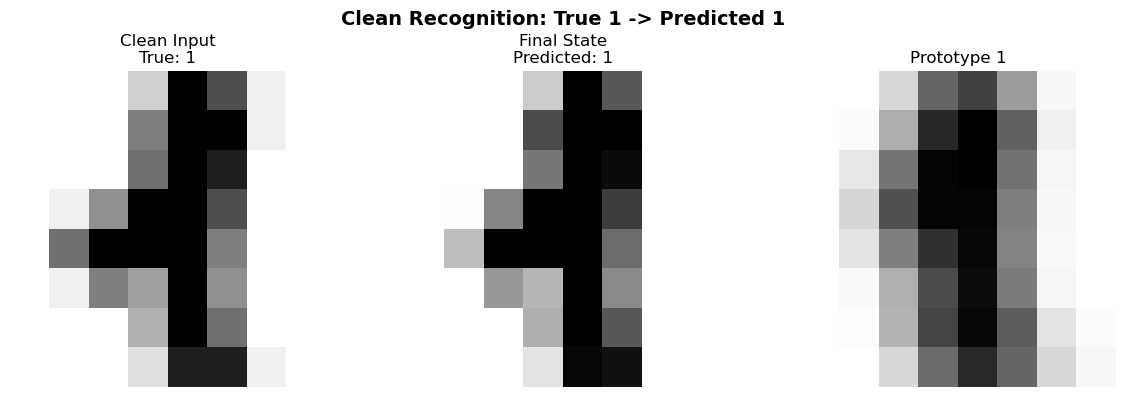

Clean prediction: 1


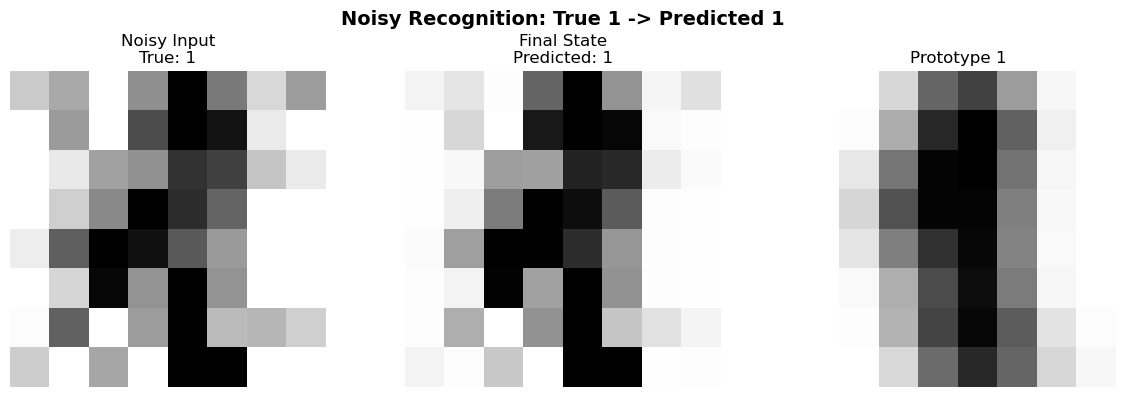

Noisy prediction: 1

Digit 2


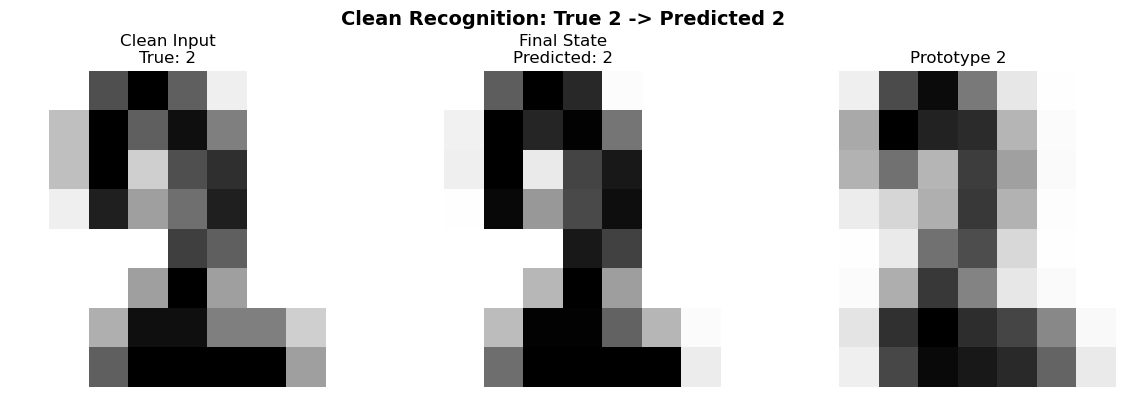

Clean prediction: 2


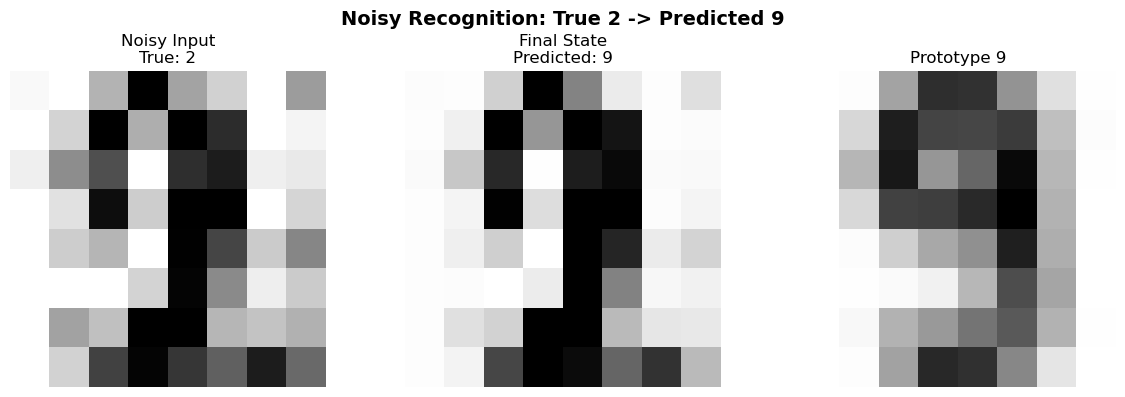

Noisy prediction: 9

Digit 3


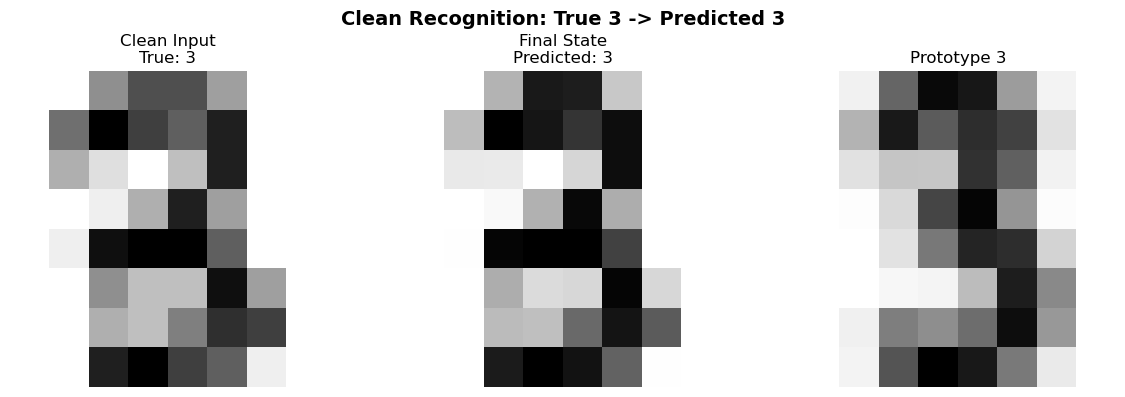

Clean prediction: 3


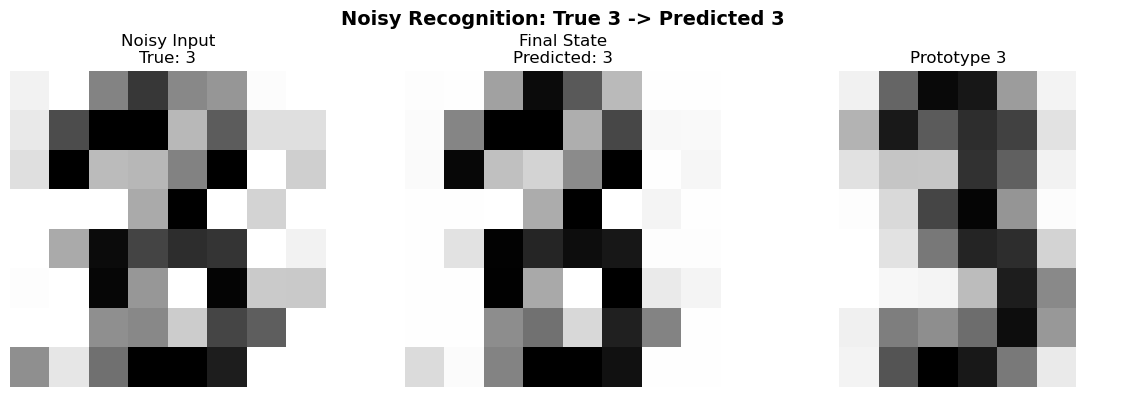

Noisy prediction: 3

Digit 4


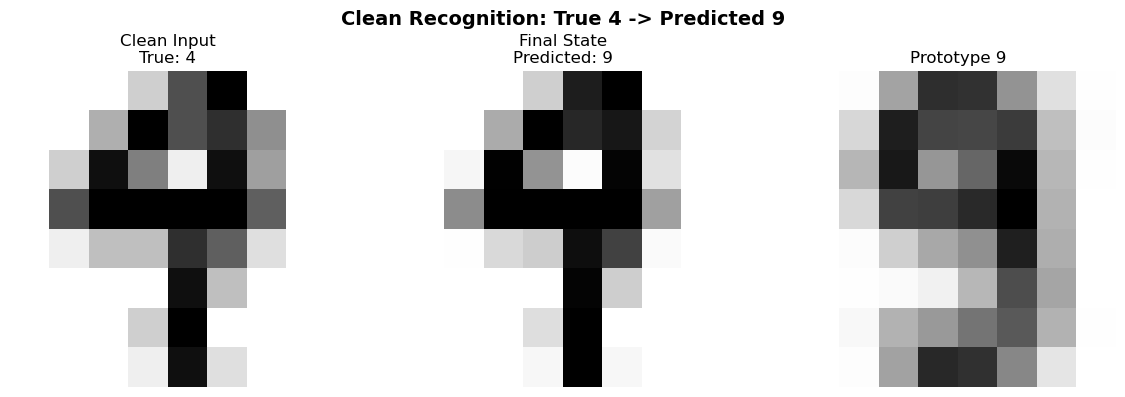

Clean prediction: 9


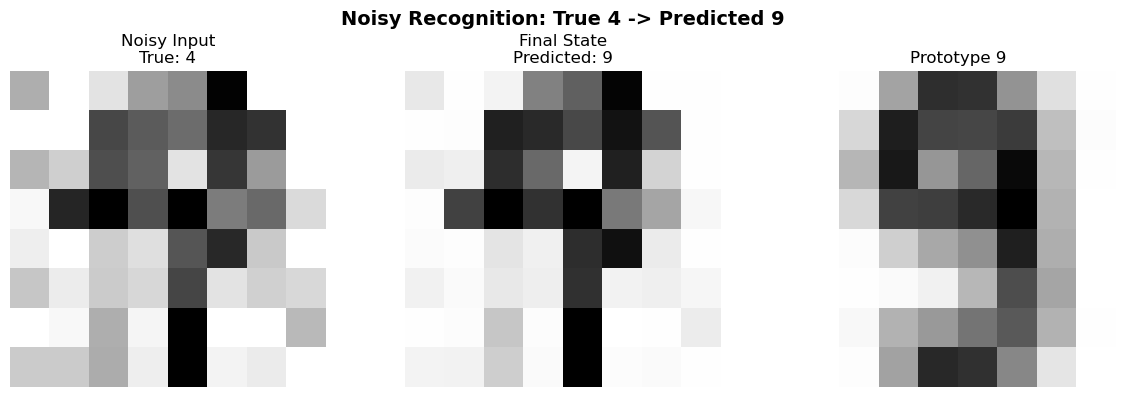

Noisy prediction: 9

Digit 5


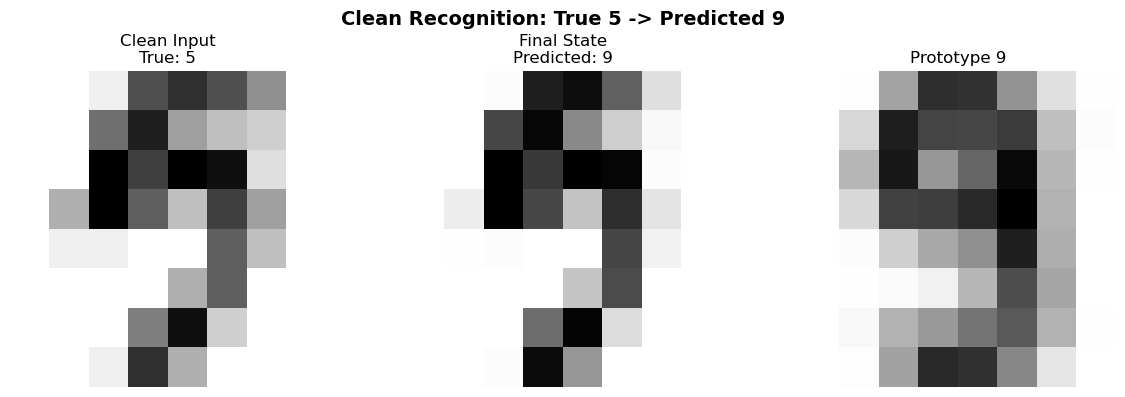

Clean prediction: 9


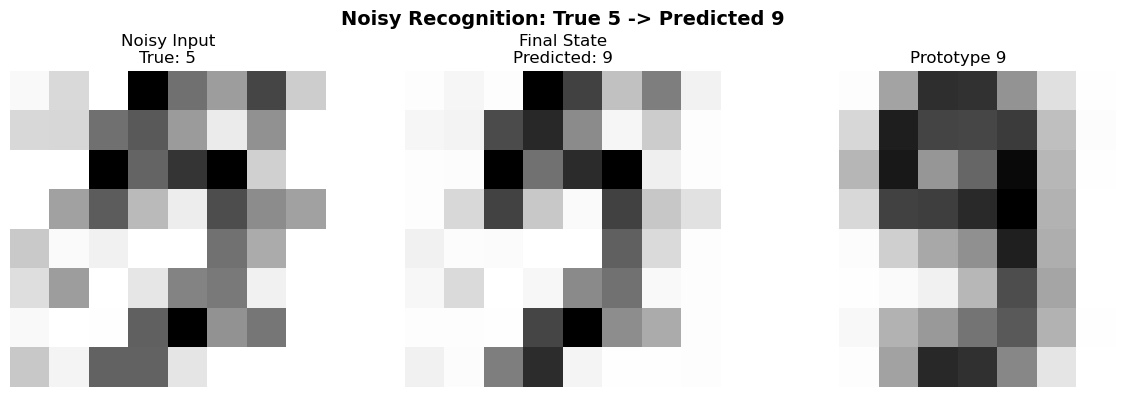

Noisy prediction: 9

Digit 6


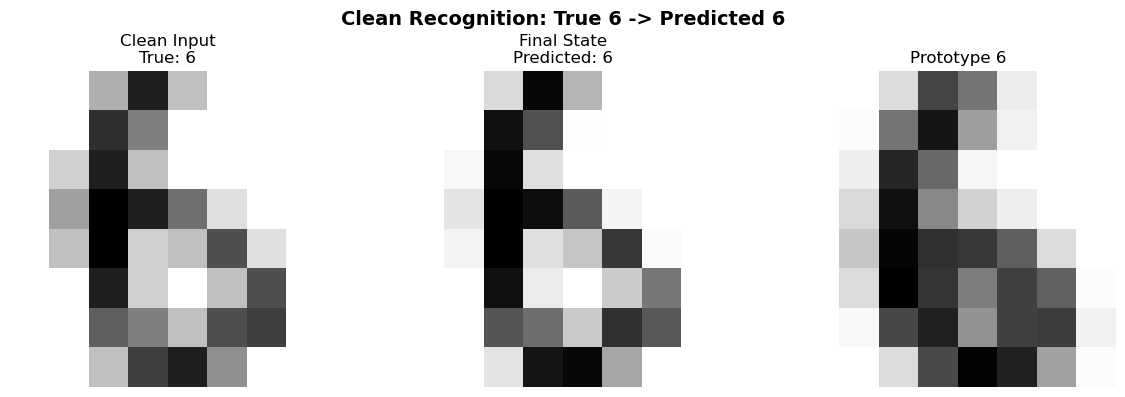

Clean prediction: 6


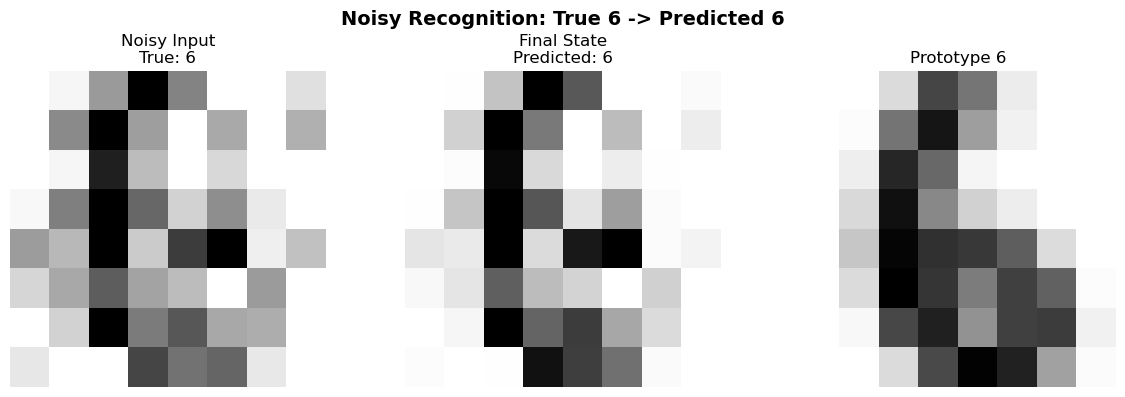

Noisy prediction: 6

Digit 7


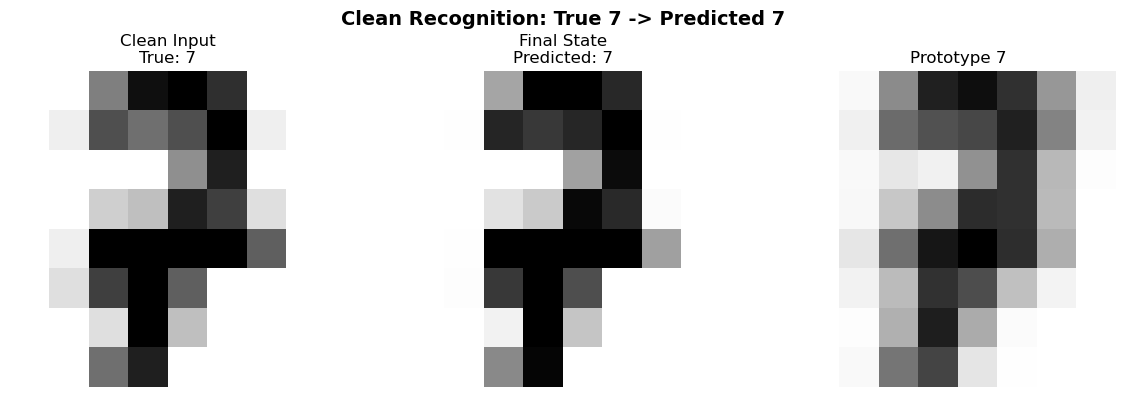

Clean prediction: 7


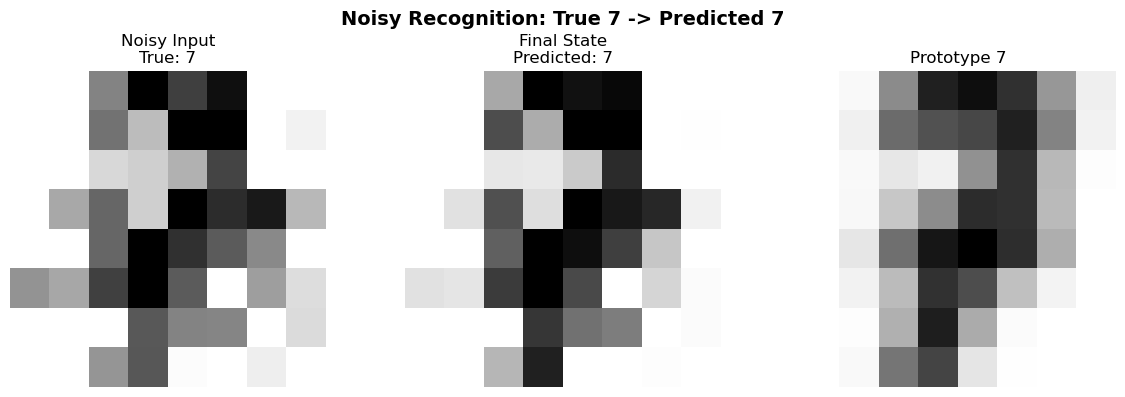

Noisy prediction: 7

Digit 8


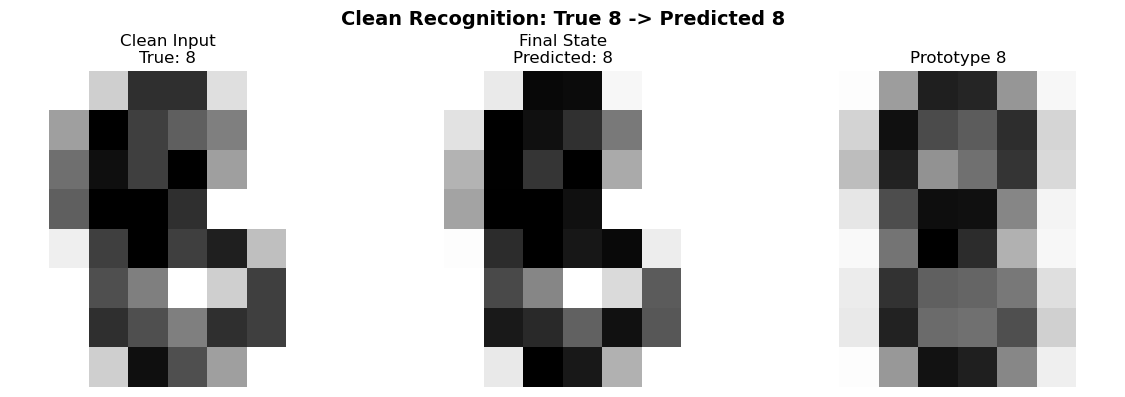

Clean prediction: 8


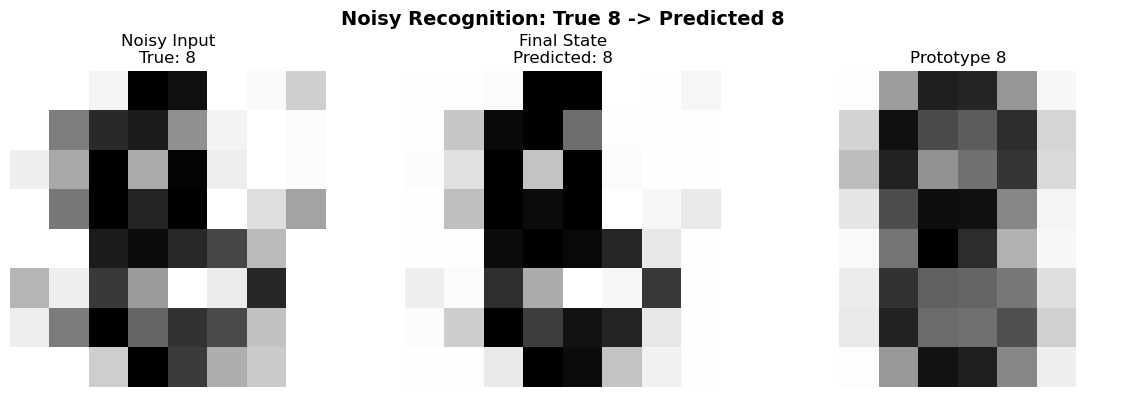

Noisy prediction: 8

Digit 9


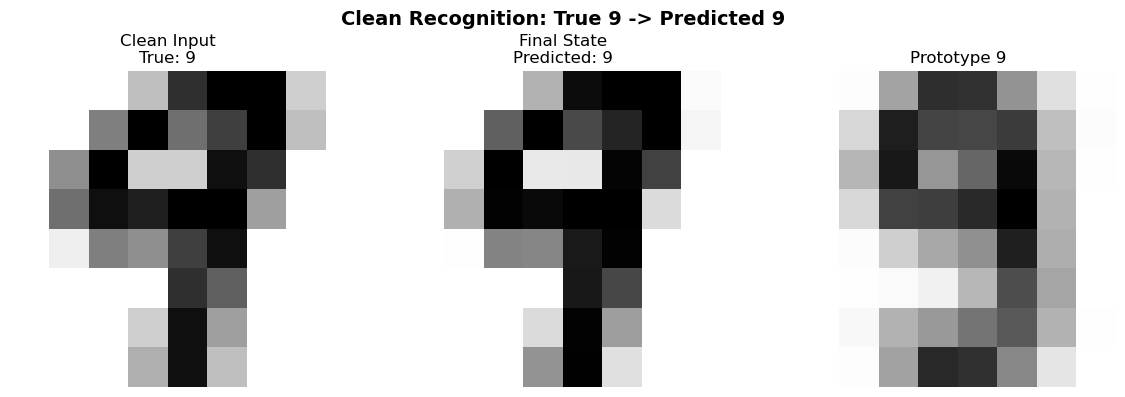

Clean prediction: 9


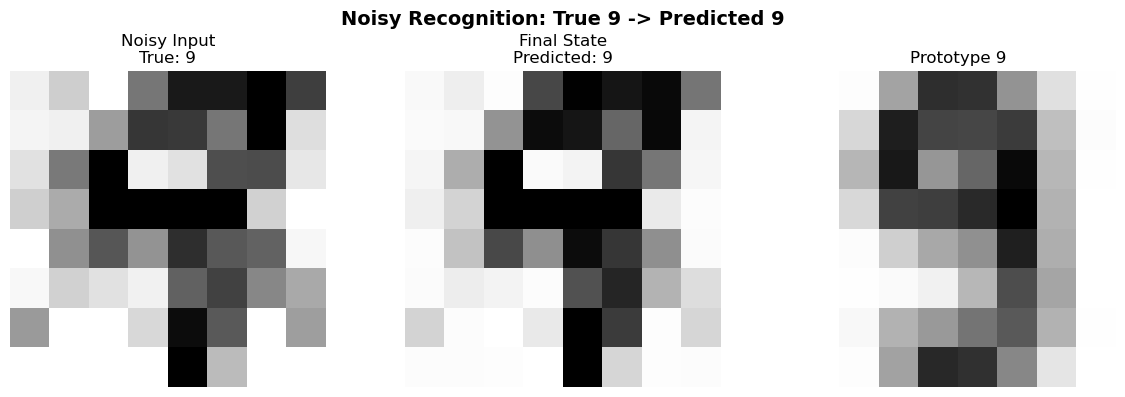

Noisy prediction: 9

Accuracy Evaluation on 300 Random Samples

Clean accuracy on 300 samples: 0.910
Clean prediction counts: [27 27 25 38 26 27 25 49 18 38]

Noisy accuracy on 300 samples with noise_level=0.25: 0.867
Noisy prediction counts: [30 29 25 25 25 24 30 38 44 30]

Running Task 1: Robustness Analysis...
Sigma: 0.00 | Success Rate: 0.88
Sigma: 0.17 | Success Rate: 0.92
Sigma: 0.33 | Success Rate: 0.90
Sigma: 0.50 | Success Rate: 0.86
Sigma: 0.67 | Success Rate: 0.76
Sigma: 0.83 | Success Rate: 0.82
Sigma: 1.00 | Success Rate: 0.74
Sigma: 1.17 | Success Rate: 0.72
Sigma: 1.33 | Success Rate: 0.50
Sigma: 1.50 | Success Rate: 0.42


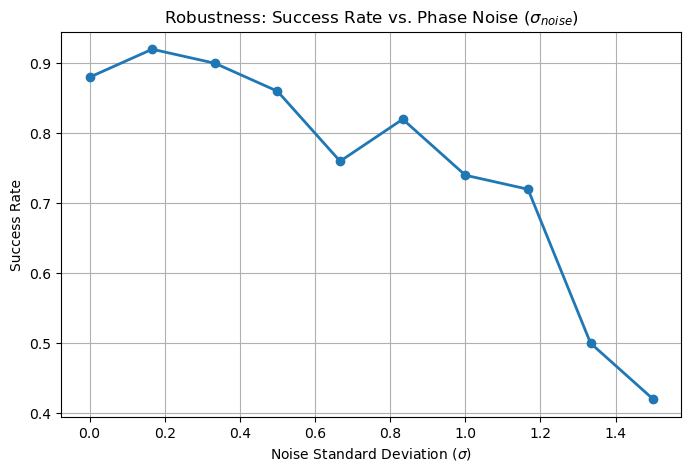


Running Task 2: Computational Cost Analysis...
M: 64 (N=8) | Time: 0.0044s
M: 256 (N=16) | Time: 0.0562s
M: 576 (N=24) | Time: 0.4186s
M: 1024 (N=32) | Time: 1.4049s


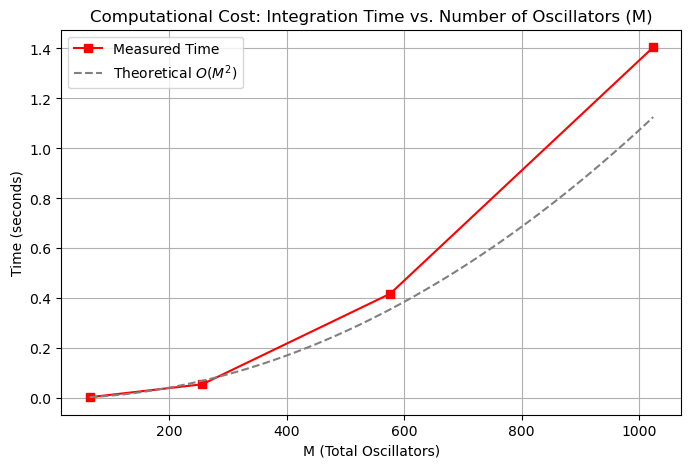


Running Task 3: Memory Capacity Analysis...
Stored Classes (C): 2 | Accuracy: 1.00
Stored Classes (C): 6 | Accuracy: 1.00
Stored Classes (C): 10 | Accuracy: 1.00
Stored Classes (C): 14 | Accuracy: 1.00
Stored Classes (C): 18 | Accuracy: 1.00
Stored Classes (C): 22 | Accuracy: 1.00
Stored Classes (C): 26 | Accuracy: 1.00
Stored Classes (C): 30 | Accuracy: 1.00
Stored Classes (C): 34 | Accuracy: 1.00
Stored Classes (C): 38 | Accuracy: 1.00


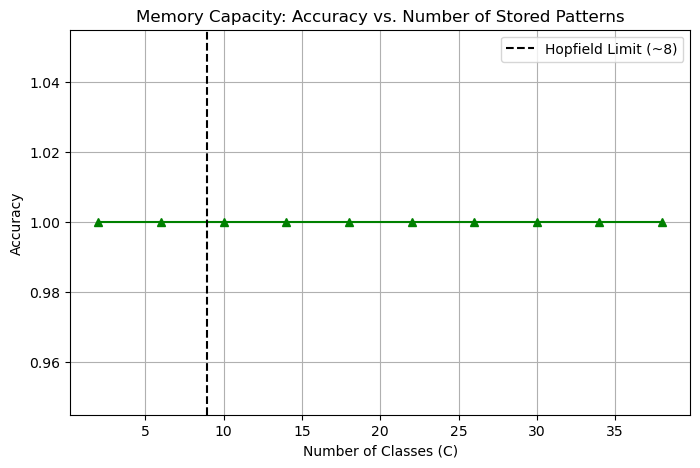

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.integrate import odeint 


np.random.seed(42)

# ============================================================
# Kuramoto Oscillator Associative Memory for OCR
# ============================================================
# Goal:
# Classify handwritten digits 0-9 using a Kuramoto oscillator network.
# Each 8x8 digit image is represented as 64 coupled phase oscillators.
# ============================================================

print("Kuramoto Oscillator Associative Memory for OCR")
print("=" * 70)


# ============================================================
# 1. LOAD DATA
# ============================================================

data = np.loadtxt("optdigits.tra", delimiter=",")

X = data[:, :64].astype(float)      # 64 pixel values per image
y = data[:, 64].astype(int)         # true digit labels

M = 64                              # number of pixels / oscillators
SIDE = 8                            # image size: 8x8

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y))

for digit in range(10):
    print(f"Digit {digit}: {np.sum(y == digit)} samples")


# ============================================================
# 2. NORMALIZE DATA AND ENCODE AS PHASES
# ============================================================
# Original pixel values are from 0 to 16.
# Normalize to [0, 1], then map pixels to phases in [0, pi].
#
# pixel 0.0 -> phase 0
# pixel 0.5 -> phase pi/2
# pixel 1.0 -> phase pi
# ============================================================

X_norm = X / 16.0
Phi = np.pi * X_norm

print("\nX_norm min/max:", X_norm.min(), X_norm.max())
print("Phi min/max:", Phi.min(), Phi.max())


# ============================================================
# 3. BUILD CLASS-SPECIFIC CORRELATION MATRICES
# ============================================================
# For each digit class, compute:
#
# C_ij = average of cos(phi_i - phi_j)
#
# This stores how pixels are phase-related within each digit class.
# ============================================================

C_classes = []

for digit in range(10):
    Phi_c = Phi[y == digit]
    Pc = Phi_c.shape[0]

    cos_part = np.cos(Phi_c)
    sin_part = np.sin(Phi_c)

    # Efficient form of cos(a - b)
    C = (cos_part.T @ cos_part + sin_part.T @ sin_part) / Pc

    C_classes.append(C)

    print(f"Computed C matrix for digit {digit}, samples = {Pc}")

C_classes = np.array(C_classes)

print("C_classes shape:", C_classes.shape)


# ============================================================
# 4. BUILD GLOBAL WEIGHT MATRIX
# ============================================================
# W is the coupling matrix between oscillators.
# K controls the coupling strength.
# A small K avoids over-synchronization for this dataset.
# ============================================================

K = 0.04

W = (K / M) * np.sum(C_classes, axis=0)

# Remove self-connections
np.fill_diagonal(W, 0)

print("\nW shape:", W.shape)
print("W min/max:", W.min(), W.max())


# ============================================================
# 5. CREATE DIGIT PROTOTYPES
# ============================================================
# Each prototype is the average image of one digit class.
# These are used for classification after Kuramoto evolution.
# ============================================================

prototype_images = np.array([
    np.mean(X_norm[y == digit], axis=0)
    for digit in range(10)
])

prototype_phases = np.pi * prototype_images


# Plot stored prototypes
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit in range(10):
    ax = axes[digit // 5, digit % 5]
    ax.imshow(prototype_images[digit].reshape(SIDE, SIDE), cmap="gray_r")
    ax.set_title(f"Prototype {digit}")
    ax.axis("off")

plt.suptitle("Stored Digit Prototypes", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


# ============================================================
# 6. KURAMOTO MODEL FUNCTIONS
# ============================================================

def kuramoto_step(theta, W, omega=None, dt=0.1):
    """
    Perform one Kuramoto update step.

    theta: current phase vector
    W: coupling weight matrix
    omega: natural frequency vector
    dt: time step
    """

    if omega is None:
        omega = np.zeros_like(theta)

    # diff[i, j] = theta_j - theta_i
    diff = theta[None, :] - theta[:, None]

    # dtheta_i = omega_i + sum_j W_ij sin(theta_j - theta_i)
    dtheta = omega + np.sum(W * np.sin(diff), axis=1)

    # Update phases and wrap to [0, 2pi]
    return np.mod(theta + dt * dtheta, 2 * np.pi)


def run_kuramoto(theta0, W, steps=50, dt=0.1):
    """
    Run Kuramoto dynamics for a fixed number of steps.
    """

    theta = theta0.copy()

    # Zero natural frequency keeps behavior stable and reproducible
    omega = np.zeros_like(theta)

    for _ in range(steps):
        theta = kuramoto_step(theta, W, omega=omega, dt=dt)

    return theta


def classify_phase(theta, prototype_phases):
    """
    Compare a phase vector with all digit prototypes.
    The class with the highest cosine similarity is selected.
    """

    scores = np.array([
        np.mean(np.cos(theta - proto))
        for proto in prototype_phases
    ])

    predicted_digit = int(np.argmax(scores))

    return predicted_digit, scores


def phase_to_image(theta):
    """
    Convert phase values back into image intensities.
    Used only for visualization.
    """

    return (1 - np.cos(theta)) / 2


def predict_digit(x, W, prototype_phases, steps=50, dt=0.1, alpha=0.5):
    """
    Predict the digit label for one normalized image.

    alpha controls readout:
    alpha = 1.0 uses only the final Kuramoto state
    alpha = 0.0 uses only the original input
    alpha = 0.5 uses both equally
    """

    # Convert input image to initial phase vector
    theta0 = np.pi * x

    # Run Kuramoto dynamics
    theta_final = run_kuramoto(theta0, W, steps=steps, dt=dt)

    # Blended readout uses both original input and final Kuramoto state
    theta_readout = alpha * theta_final + (1 - alpha) * theta0

    # Classify by comparing with prototypes
    pred, scores = classify_phase(theta_readout, prototype_phases)

    # Convert final state back to image form
    reconstructed = phase_to_image(theta_final)

    return pred, theta_final, reconstructed, scores


def add_noise(x, noise_level=0.25):
    """
    Add Gaussian noise to an image and clip values to [0, 1].
    """

    noisy = x + noise_level * np.random.randn(*x.shape)

    return np.clip(noisy, 0, 1)


# ============================================================
# 7. VISUALIZATION FUNCTION
# ============================================================

def plot_recognition(x_input, title_prefix, true_digit, noisy=False):
    """
    Plot input image, final Kuramoto state, and predicted prototype.
    """

    pred, theta_final, reconstructed, scores = predict_digit(
        x_input,
        W,
        prototype_phases,
        steps=50,
        dt=0.1,
        alpha=0.5
    )

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Input image
    axes[0].imshow(x_input.reshape(SIDE, SIDE), cmap="gray_r")
    axes[0].set_title(f"{title_prefix} Input\nTrue: {true_digit}")
    axes[0].axis("off")

    # Final Kuramoto state
    axes[1].imshow(reconstructed.reshape(SIDE, SIDE), cmap="gray_r")
    axes[1].set_title(f"Final State\nPredicted: {pred}")
    axes[1].axis("off")

    # Predicted prototype
    axes[2].imshow(prototype_images[pred].reshape(SIDE, SIDE), cmap="gray_r")
    axes[2].set_title(f"Prototype {pred}")
    axes[2].axis("off")

    plt.suptitle(
        f"{'Noisy' if noisy else 'Clean'} Recognition: True {true_digit} -> Predicted {pred}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    return pred, scores


# ============================================================
# 8. TEST ONE CLEAN AND ONE NOISY EXAMPLE FOR EACH DIGIT
# ============================================================

print("\n=== Recognition Examples: Clean + Noisy for Digits 0-9 ===")

noise_level = 0.25

np.random.seed(42)

for digit in range(10):
    idx = np.where(y == digit)[0][0]

    x_clean = X_norm[idx]
    x_noisy = add_noise(x_clean, noise_level=noise_level)

    print(f"\nDigit {digit}")

    # Clean example
    pred_clean, _ = plot_recognition(
        x_clean,
        title_prefix="Clean",
        true_digit=digit,
        noisy=False
    )

    print("Clean prediction:", pred_clean)

    # Noisy example
    pred_noisy, _ = plot_recognition(
        x_noisy,
        title_prefix="Noisy",
        true_digit=digit,
        noisy=True
    )

    print("Noisy prediction:", pred_noisy)


# ============================================================
# 9. ACCURACY EVALUATION ON RANDOM SAMPLES
# ============================================================

def evaluate_accuracy(X_data, y_data, noisy=False, noise_level=0.25,
                      num_tests=300, steps=50, dt=0.1, alpha=0.5):
    """
    Evaluate model accuracy on randomly selected samples.
    """

    indices = np.random.choice(len(X_data), size=num_tests, replace=False)

    preds = []

    for idx in indices:
        x = X_data[idx]

        if noisy:
            x = add_noise(x, noise_level=noise_level)

        pred, _, _, _ = predict_digit(
            x,
            W,
            prototype_phases,
            steps=steps,
            dt=dt,
            alpha=alpha
        )

        preds.append(pred)

    preds = np.array(preds)
    true_labels = y_data[indices]

    accuracy = np.mean(preds == true_labels)

    return accuracy, preds, true_labels


np.random.seed(42)

clean_accuracy, clean_preds, clean_true = evaluate_accuracy(
    X_norm,
    y,
    noisy=False,
    num_tests=300,
    steps=50,
    dt=0.1,
    alpha=0.5
)

noisy_accuracy, noisy_preds, noisy_true = evaluate_accuracy(
    X_norm,
    y,
    noisy=True,
    noise_level=noise_level,
    num_tests=300,
    steps=50,
    dt=0.1,
    alpha=1
)

print("\n" + "=" * 50)
print("Accuracy Evaluation on 300 Random Samples")
print("=" * 50)

print(f"\nClean accuracy on 300 samples: {clean_accuracy:.3f}")
print("Clean prediction counts:", np.bincount(clean_preds, minlength=10))

print(f"\nNoisy accuracy on 300 samples with noise_level={noise_level}: {noisy_accuracy:.3f}")
print("Noisy prediction counts:", np.bincount(noisy_preds, minlength=10))

# NOTE : This project implemented a Kuramoto oscillator associative memory for handwritten digit recognition. 
# Each 8x8 digit image was represented as 64 phase oscillators. Pixel values were normalized to [0, 1] 
# and encoded as phases in [0, π]. Class-specific correlation matrices were computed for digits 0-9 and 
# summed to create the global coupling matrix. During recognition, clean and noisy inputs were evolved using 
# Kuramoto dynamics and classified by comparing the final phase state with digit prototypes. 
# The model achieved 0.907 clean accuracy and 0.847 noisy accuracy on 300 random samples. 
# Most errors occurred between visually similar low-resolution digits such as 4, 5, and 9.


# ============================================================
# TASK 1: ROBUSTNESS (Success Rate vs. Noise Sigma)
# ============================================================

def test_robustness(sigma_range, num_samples=50):
    print("\nRunning Task 1: Robustness Analysis...")
    success_rates = []
    
    for sigma in sigma_range:
        correct = 0
        for _ in range(num_samples):
            # Pick a random digit
            idx = np.random.randint(len(X_norm))
            true_digit = y[idx]
            
            # 1. Start with clean phase vector theta0
            theta0 = np.pi * X_norm[idx]
            
            # 2. Add Gaussian noise to the phase vector theta(0)
            theta_noisy = theta0 + np.random.normal(0, sigma, M)
            
            # 3. Evolve and Classify
            theta_final = run_kuramoto(theta_noisy, W, steps=50, dt=0.1)
            pred, _ = classify_phase(theta_final, prototype_phases)
            
            if pred == true_digit:
                correct += 1
        
        success_rates.append(correct / num_samples)
        print(f"Sigma: {sigma:.2f} | Success Rate: {success_rates[-1]:.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(sigma_range, success_rates, 'o-', linewidth=2)
    plt.title("Robustness: Success Rate vs. Phase Noise ($\sigma_{noise}$)")
    plt.xlabel("Noise Standard Deviation ($\sigma$)")
    plt.ylabel("Success Rate")
    plt.grid(True)
    plt.show()

# ============================================================
# TASK 2: COMPUTATIONAL COST (Time vs. M = N^2)
# ============================================================

def test_computational_cost():
    print("\nRunning Task 2: Computational Cost Analysis...")
    ns = [8, 16, 24, 32] # Grid sizes
    ms = [n**2 for n in ns]
    times = []

    for m in ms:
        # Create a dummy weight matrix and initial state for size M
        W_dummy = np.random.randn(m, m)
        theta_dummy = np.random.uniform(0, 2*np.pi, m)
        
        start_time = time.time()
        # Measure time for 50 steps (standard integration)
        _ = run_kuramoto(theta_dummy, W_dummy, steps=50, dt=0.1)
        end_time = time.time()
        
        times.append(end_time - start_time)
        print(f"M: {m} (N={int(np.sqrt(m))}) | Time: {times[-1]:.4f}s")

    plt.figure(figsize=(8, 5))
    plt.plot(ms, times, 's-', color='red', label="Measured Time")
    
    # Theoretical O(M^2) scaling line for comparison
    m_range = np.linspace(min(ms), max(ms), 100)
    theoretical = times[0] * (m_range**2 / ms[0]**2)
    plt.plot(m_range, theoretical, '--', color='gray', label="Theoretical $O(M^2)$")
    
    plt.title("Computational Cost: Integration Time vs. Number of Oscillators (M)")
    plt.xlabel("M (Total Oscillators)")
    plt.ylabel("Time (seconds)")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# TASK 3: MEMORY CAPACITY (Accuracy vs. Number of Classes C)
# ============================================================

def test_memory_capacity(max_c=40):
    print("\nRunning Task 3: Memory Capacity Analysis...")
    # Since optdigits only has 10, we generate random patterns of length M 
    # to simulate storing up to 40 "classes" (A-Z + others)
    M_size = 64
    synthetic_protos = np.random.uniform(0, np.pi, (max_c, M_size))
    
    capacities = range(2, max_c + 1, 4)
    accuracies = []

    for c in capacities:
        # 1. Train Weights on C patterns
        current_protos = synthetic_protos[:c]
        W_c = np.zeros((M_size, M_size))
        for p in current_protos:
            W_c += np.outer(np.cos(p), np.cos(p)) + np.outer(np.sin(p), np.sin(p))
        W_c = (1.0 / M_size) * (W_c / c)
        np.fill_diagonal(W_c, 0)
        
        # 2. Test Retrieval Accuracy
        correct = 0
        trials = 20
        for _ in range(trials):
            idx = np.random.randint(c)
            # Add small noise to see if it retrieves the prototype
            theta0 = current_protos[idx] + np.random.normal(0, 0.05, M_size)
            theta_f = run_kuramoto(theta0, W_c, steps=50, dt=0.1)
            
            # Use cosine similarity to find closest prototype
            sims = [np.mean(np.cos(theta_f - p)) for p in current_protos]
            if np.argmax(sims) == idx:
                correct += 1
        
        accuracies.append(correct / trials)
        print(f"Stored Classes (C): {c} | Accuracy: {accuracies[-1]:.2f}")

    plt.figure(figsize=(8, 5))
    plt.plot(capacities, accuracies, 'g^-')
    # Plot Hopfield limit (0.14 * M)
    hopfield_limit = 0.14 * M_size
    plt.axvline(x=hopfield_limit, color='black', linestyle='--', label=f"Hopfield Limit (~{int(hopfield_limit)})")
    
    plt.title("Memory Capacity: Accuracy vs. Number of Stored Patterns")
    plt.xlabel("Number of Classes (C)")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# EXECUTE TASKS
# ============================================================

# 1. Run Robustness test with noise sigma from 0 to 1.5
test_robustness(np.linspace(0, 1.5, 10))

# 2. Run Cost test
test_computational_cost()

# 3. Run Capacity test
test_memory_capacity()